# Learn about Obi-Wan Kenobi

Are you a star wars fan? If not, this exercise will help you learn about one of the most important character of the saga: Obi-Wan Kenobi. We will scrap a wikipedia page and create a word cloud to understand what comes out of the article. 

* To focus on NLP, let's use the following code to retrieve a clean HTML page from a variable. We will see later in the program how it works: 

```
import requests
from bs4 import BeautifulSoup
r = requests.get( "https://fr.wikipedia.org/wiki/Obi-Wan_Kenobi" )
html_doc = r.text
soup = BeautifulSoup(html_doc, 'html.parser')

corpus = [ ]
for p in soup.find_all("p"):
  corpus.append(p.text)
```

In [25]:
import requests
from bs4 import BeautifulSoup
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}

r = requests.get( "https://fr.wikipedia.org/wiki/Obi-Wan_Kenobi", headers=headers)
html_doc = r.text
soup = BeautifulSoup(html_doc, 'html.parser')

corpus = [ ]
for p in soup.find_all("p"):
  corpus.append(p.text)


* We need to install `spacy` modules corresponding to the language specifics (in this case French). So install `en_core_news_sm`. 
  * Feel free to help you with documentation: [English](https://spacy.io/models/fr)

In [26]:
import spacy
# Import English using en_core_web_sm.load()
import en_core_web_sm
nlp_en = en_core_web_sm.load()

* Since text is in french, import now `fr_core_news_sm` --> [Documentation](https://spacy.io/models)

In [27]:
# nlp_fr = spacy.load("fr_core_news_sm")
nlp_fr = spacy.load("fr_core_news_sm")

* For the rest, we need to create a complete corpus of text in a variable. This is a best-practice in the use of spacy. So you will need to create a clean corpus of text. You can do this with the help of : 
  * join()
  * strip() 
  
* Make some basic cleanings :
  * remove special characters
  * make sure there are no uppercase

In [28]:
corpus

['Pour les articles homonymes, voir Obi-Wan Kenobi (homonymie).\n',
 'Personnage de fiction apparaissant dansStar Wars.',
 '\n',
 '\n',
 '\n',
 '\n',
 '\n',
 '\n',
 'modifier ',
 "Obi-Wan Kenobi, également dit Ben Kenobi, est un personnage de fiction dans l'univers de la série cinématographique Star Wars, créée par George Lucas. Il est un chevalier et maître Jedi, personnage emblématique de la saga. Il fut, jusqu'à la sortie de Rogue One en 2016, l'un des seuls personnages à faire son apparition dans chaque film, que ce soit en présence réelle, en forme de «\xa0fantôme\xa0», ou même simplement en caméo où l'on n'entend que sa voix.\n",
 "Il est tout d'abord le padawan de Qui-Gon Jinn avant de devenir lui-même l'instructeur d'Anakin Skywalker, puis de le laisser pour mort à l'issue d'un terrible combat après que ce dernier a choisi le côté obscur de la Force pour devenir Dark Vador, Seigneur Noir des Sith, bras armé de l'empereur galactique Palpatine ou Dark Sidious. Ces évènements sont

In [29]:
del corpus[0:9]
del corpus[-2:]
corpus

["Obi-Wan Kenobi, également dit Ben Kenobi, est un personnage de fiction dans l'univers de la série cinématographique Star Wars, créée par George Lucas. Il est un chevalier et maître Jedi, personnage emblématique de la saga. Il fut, jusqu'à la sortie de Rogue One en 2016, l'un des seuls personnages à faire son apparition dans chaque film, que ce soit en présence réelle, en forme de «\xa0fantôme\xa0», ou même simplement en caméo où l'on n'entend que sa voix.\n",
 "Il est tout d'abord le padawan de Qui-Gon Jinn avant de devenir lui-même l'instructeur d'Anakin Skywalker, puis de le laisser pour mort à l'issue d'un terrible combat après que ce dernier a choisi le côté obscur de la Force pour devenir Dark Vador, Seigneur Noir des Sith, bras armé de l'empereur galactique Palpatine ou Dark Sidious. Ces évènements sont relatés dans la prélogie (épisodes I, II et III).\n",
 "Dans la trilogie originale (épisodes IV, V et VI), qui raconte les évènements survenant deux décennies plus tard, le viei

In [33]:
# Afficher les premiers caractères avec leur code Unicode
print(repr(corpus[0][:10]))  # Affiche les 10 premiers caractères
print([ord(c) for c in corpus[0][:5]]) 

'Obi-Wan Ke'
[79, 98, 105, 45, 87]


In [34]:
# Voir si il y a des sauts de ligne
print('\\n' in corpus[0])  # True si il y en a
print(corpus[0].count('\n')) 

False
1


In [35]:
# Supprimer tous les \n de tous les éléments
corpus = [p.replace('\n', ' ') for p in corpus]

# Ou si vous voulez aussi nettoyer les espaces multiples qui pourraient résulter
corpus = [' '.join(p.split()) for p in corpus]

In [39]:
for i in range(len(corpus)):
    corpus[i] = corpus[i].lower()

corpus

["obi-wan kenobi, également dit ben kenobi, est un personnage de fiction dans l'univers de la série cinématographique star wars, créée par george lucas. il est un chevalier et maître jedi, personnage emblématique de la saga. il fut, jusqu'à la sortie de rogue one en 2016, l'un des seuls personnages à faire son apparition dans chaque film, que ce soit en présence réelle, en forme de « fantôme », ou même simplement en caméo où l'on n'entend que sa voix.",
 "il est tout d'abord le padawan de qui-gon jinn avant de devenir lui-même l'instructeur d'anakin skywalker, puis de le laisser pour mort à l'issue d'un terrible combat après que ce dernier a choisi le côté obscur de la force pour devenir dark vador, seigneur noir des sith, bras armé de l'empereur galactique palpatine ou dark sidious. ces évènements sont relatés dans la prélogie (épisodes i, ii et iii).",
 "dans la trilogie originale (épisodes iv, v et vi), qui raconte les évènements survenant deux décennies plus tard, le vieil obi-wan,

* Now load your clean corpus in a `doc` object.

In [44]:
# Joindre tous les paragraphes
texte_complet = ' '.join(corpus)
doc = nlp_fr(texte_complet)
doc

obi-wan kenobi, également dit ben kenobi, est un personnage de fiction dans l'univers de la série cinématographique star wars, créée par george lucas. il est un chevalier et maître jedi, personnage emblématique de la saga. il fut, jusqu'à la sortie de rogue one en 2016, l'un des seuls personnages à faire son apparition dans chaque film, que ce soit en présence réelle, en forme de « fantôme », ou même simplement en caméo où l'on n'entend que sa voix. il est tout d'abord le padawan de qui-gon jinn avant de devenir lui-même l'instructeur d'anakin skywalker, puis de le laisser pour mort à l'issue d'un terrible combat après que ce dernier a choisi le côté obscur de la force pour devenir dark vador, seigneur noir des sith, bras armé de l'empereur galactique palpatine ou dark sidious. ces évènements sont relatés dans la prélogie (épisodes i, ii et iii). dans la trilogie originale (épisodes iv, v et vi), qui raconte les évènements survenant deux décennies plus tard, le vieil obi-wan, qui se fa

* With the `wordcloud` library, create a first word cloud 

In [ ]:
# Import matplotlib and wordcloud 
import matplotlib.pyplot as plt
import wordcloud

# Instanciate WordCloud 
wd = wordcloud.WordCloud()
cloud = wd.generate(doc.text)

# Show word cloud with matplotlib 
plt.imshow(cloud)

# Remove trailing logs 
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'starwars_logo.jpg'

* Now import the stop-words present in `spacy`

In [46]:
from spacy.lang.fr.stop_words import STOP_WORDS

# Print stop words
print(STOP_WORDS)

{'specifiques', 'ces', 'd’', 'eux', 'qui', 'permet', 'ainsi', 'dix-neuf', 'cependant', 'fais', 'sinon', 'houp', 'comment', 'le', 'suit', 'combien', 'me', 'uns', 'nombreux', 'étant', 'encore', 'différent', 'sept', 'dit', 'hi', 'plusieurs', 'septième', 'malgre', 'cette', 'chacun', 'elle-meme', 'plus', 'merci', 'voila', 'bat', 'quant-à-soi', 'toi-meme', 'eux-mêmes', 'lors', 'dejà', 'également', 'ceux-là', 'anterieures', 'parler', 'nôtre', "l'", 'antérieures', 'quatre-vingt', 'restent', 'soi', 'précisement', 'antérieure', 'puis', 'eu', 'mienne', 'tiens', 'notre', 'tels', 'differente', 'tiennes', 'sur', "j'", 'etaient', 'aurait', 'néanmoins', 'du', 'de', 'ho', 'pour', 'comme', 'onzième', 'precisement', 'divers', 'peu', 'ouvert', 'trois', 'suffisante', 'ton', 'premièrement', 'hé', 'sous', 'neuvième', 'selon', 'moi-même', 'outre', 'quatrièmement', 'tente', 'semblaient', 'malgré', 'suivantes', 'c’', 'quant', 'pres', 'directe', 'as', 'o', 'personne', 'sont', 'celle', 'nombreuses', 'tienne', 'ci

In [49]:
from spacy.lang.fr.stop_words import STOP_WORDS

# # Print stop words
# for token in doc:
#     if token.text in STOP_WORDS:
#         print(token.text)

for token in doc:
    if token.is_stop:  # spaCy a déjà identifié les stop words
        print(token.text)

également
dit
est
un
de
dans
l'
de
la
par
il
est
un
et
de
la
il
à
la
de
en
l'
un
des
seuls
à
son
dans
chaque
que
ce
soit
en
en
de
ou
même
en
où
l'
on
n'
que
sa
il
est
tout
d'
abord
le
de
qui
avant
de
lui-même
l'
d'
puis
de
le
laisser
pour
à
l'
d'
un
après
que
ce
a
le
de
la
pour
des
de
l'
ou
ces
sont
dans
la
i
et
dans
la
et
qui
les
deux
plus
le
qui
se
fait
désormais
le
d'
et
sur
le
de
la
avant
d'
être
par
il
cependant
sous
d'
pour
est
par
dans
la
que
sa
plus
l'
est
par
dans
la
une
qui
lui
est
entre
les
et
est
en
sur
où
son
tout
comme
celui
de
lorsque
la
du
par
d'
un
sur
le
de
la
deux
qui
et
pour
une
du
les
de
la
de
de
qui
et
les
deux
à
l'
en
se
sous
la
de
ils
y
puis
la
de
afin
de
lui
de
la
pour
plutôt
sa
à
du
le
doit
cependant
se
sur
en
afin
de
les
à
la
du
et
y
un
dans
la
que
qui
à
afin
de
l'
hors
de
alors
qu'
à
qui
son
de
est
pour
le
les
deux
à
où
ils
le
qui
se
par
mais
le
que
la
du
est
malgré
la
de
qui
et
le
du
et
de
dans
un
premier
comme
en
qu'
il
ainsi
l'
dans
la
il
ainsi
les
que
qu

* Make a word cloud again without the stop words

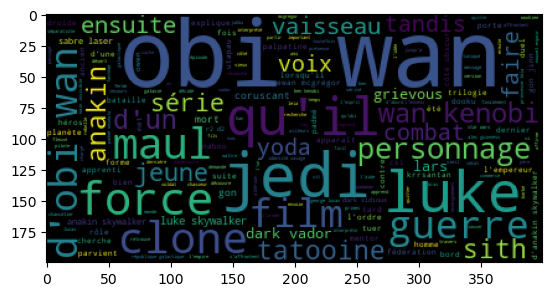

In [ ]:
# Instanciate WordCloud 
wd = wordcloud.WordCloud(stopwords=STOP_WORDS)
cloud = wd.generate(doc.text)

# Show word cloud with matplotlib 
plt.imshow(cloud)

# Remove trailing logs 
plt.show()

* We would need to have a corpus of lemmatized words, recreate a corpus of lemmatized words and visualize your new word cloud

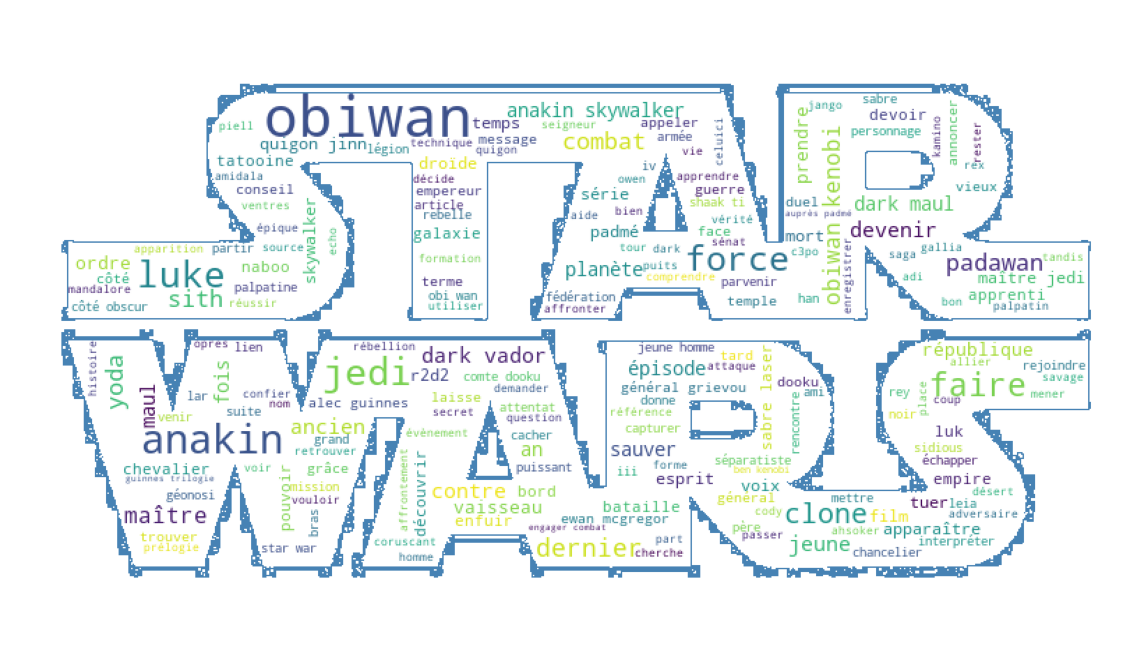

* Let's push analysis further! Some words are really common in our corpus, find which of them

obiwan    True
anakin    True
          True
jedi      True
luke      True
force     True
dark      True
faire     True
»         True
«         True
dtype: bool

* Update your list of stop words with the common words

* Create a new word cloud 

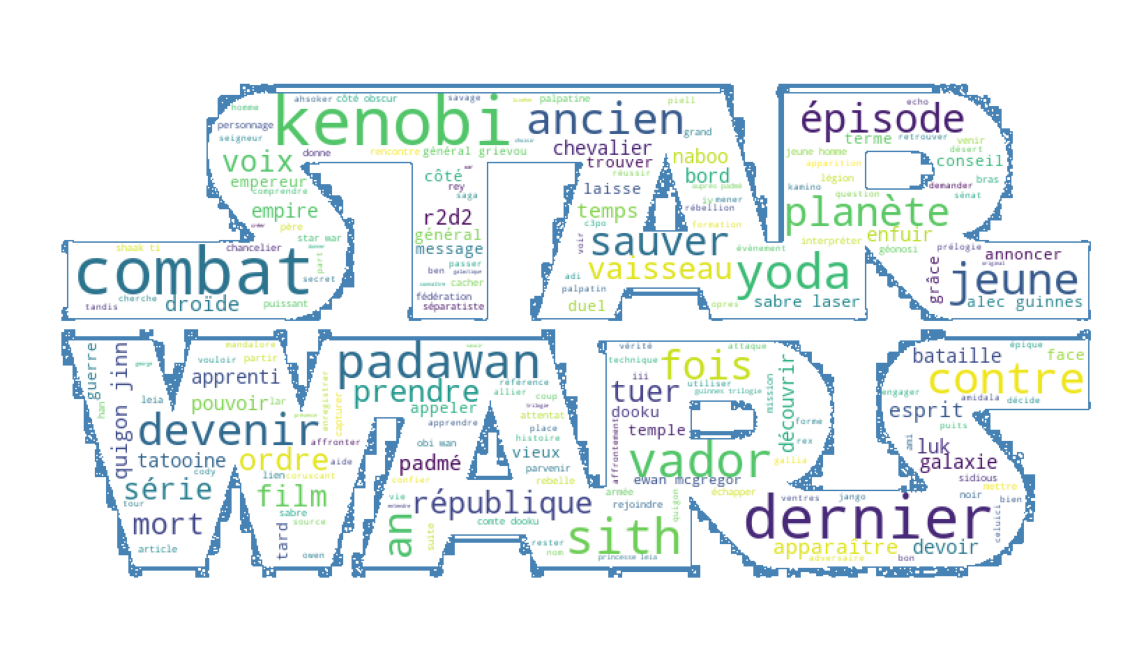

* We will now start building a tf-idf matrix. Let's first create a DataFrame containing our lemmatized corpus without the updated stop words.

In [56]:
import pandas as pd
df = pd.DataFrame()
df["documents"] = corpus
df

,documents
0,"obi-wan kenobi, également dit ben kenobi, est ..."
1,il est tout d'abord le padawan de qui-gon jinn...
2,"dans la trilogie originale (épisodes iv, v et ..."
3,kenobi âgé est interprété par alec guinness da...
4,"lorsque la fédération du commerce, manipulée s..."
...,...
72,"ainsi, la mort d'obi-wan, tué par dark vador, ..."
73,plusieurs mèmes sur obi-wan sont répandues sur...
74,l'émission télévisée qui veut gagner des milli...
75,"la municipalité de lubicz, non loin de toruń, ..."


In [57]:
import re
df['clean_documents'] = df['documents'].apply(lambda x: re.sub('[!\"#$%&()*+,-./:;<=>?@\[\]^_`{|}~\\\]+'," ", x))
df

,documents,clean_documents
0,"obi-wan kenobi, également dit ben kenobi, est ...",obi wan kenobi également dit ben kenobi est ...
1,il est tout d'abord le padawan de qui-gon jinn...,il est tout d'abord le padawan de qui gon jinn...
2,"dans la trilogie originale (épisodes iv, v et ...",dans la trilogie originale épisodes iv v et ...
3,kenobi âgé est interprété par alec guinness da...,kenobi âgé est interprété par alec guinness da...
4,"lorsque la fédération du commerce, manipulée s...",lorsque la fédération du commerce manipulée s...
...,...,...
72,"ainsi, la mort d'obi-wan, tué par dark vador, ...",ainsi la mort d'obi wan tué par dark vador ...
73,plusieurs mèmes sur obi-wan sont répandues sur...,plusieurs mèmes sur obi wan sont répandues sur...
74,l'émission télévisée qui veut gagner des milli...,l'émission télévisée qui veut gagner des milli...
75,"la municipalité de lubicz, non loin de toruń, ...",la municipalité de lubicz non loin de toruń ...


In [59]:

## Tokenize the cleaned document
tokenized_doc = df['clean_documents'].fillna('').apply(lambda x: nlp_fr(x))

# remove stop-words
tokenized_doc = tokenized_doc.apply(lambda x: [token.lemma_ for token in x if token.text not in STOP_WORDS])
tokenized_doc


0     [obi, wan, kenobi,  , ben, kenobi,  , personna...
1     [padawan, gon, jinn, devenir, instructeur, ana...
2     [trilogie, original,  , épisode, iv,  , v, vi,...
3     [kenobi, âgé, interpréter, alec, guinnes, tril...
4     [fédération, commerce,  , manipuler, secrèteme...
                            ...                        
72    [ , mort, obi, wan,  , tuer, dark, vador,  , e...
73    [mème, obi, wan, répandre, web,  , reprendre, ...
74    [émission, téléviser, vouloir, gagner, million...
75    [municipalité, lubicz,  , non, loin, toruń,  ,...
76    [obi, wan, nom, night, club, shanghai, échappe...
Name: clean_documents, Length: 77, dtype: object

In [60]:
df["clean_token"] = [" ".join(x) for x in tokenized_doc]
df.head()

,documents,clean_documents,clean_token
0,"obi-wan kenobi, également dit ben kenobi, est ...",obi wan kenobi également dit ben kenobi est ...,obi wan kenobi ben kenobi personnage ficti...
1,il est tout d'abord le padawan de qui-gon jinn...,il est tout d'abord le padawan de qui gon jinn...,padawan gon jinn devenir instructeur anakin sk...
2,"dans la trilogie originale (épisodes iv, v et ...",dans la trilogie originale épisodes iv v et ...,trilogie original épisode iv v vi racont...
3,kenobi âgé est interprété par alec guinness da...,kenobi âgé est interprété par alec guinness da...,kenobi âgé interpréter alec guinnes trilogie o...
4,"lorsque la fédération du commerce, manipulée s...",lorsque la fédération du commerce manipulée s...,fédération commerce manipuler secrètement da...


* Let's create now a TF-IDF matrix using `sklearn`

In [61]:
# Tfidf transformer 
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF vector
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(df['clean_token'])

# X is a generator. We can transform that as an array
dense = X.toarray()
dense

array([[0.        , 0.        , 0.        , ..., 0.        , 0.13917782,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.18705614, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.20609746, 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

* Visualize most important words using `seaborn`, `matplotlib` or `plotly`

> Help: You can create a dataframe, transpose it and then easily create a visualization

In [62]:
# Get tokens for all documents
vectorizer.vocabulary_

{'obi': 648,
 'wan': 1039,
 'kenobi': 554,
 'ben': 146,
 'personnage': 698,
 'fiction': 411,
 'univers': 998,
 'série': 940,
 'cinématographique': 203,
 'star': 915,
 'war': 1040,
 'créer': 276,
 'george': 441,
 'luca': 580,
 'chevalier': 195,
 'maître': 600,
 'jedi': 538,
 'emblématique': 348,
 'saga': 859,
 'être': 1075,
 'jusque': 549,
 'sortie': 903,
 'rogue': 823,
 '2016': 15,
 'faire': 399,
 'apparition': 97,
 'film': 414,
 'présence': 753,
 'réel': 835,
 'forme': 430,
 'fantôme': 402,
 'simplement': 888,
 'caméo': 172,
 'entendre': 372,
 'voix': 1030,
 'padawan': 674,
 'gon': 444,
 'jinn': 543,
 'devenir': 292,
 'instructeur': 509,
 'anakin': 87,
 'skywalker': 895,
 'mort': 622,
 'issue': 526,
 'terrible': 962,
 'combat': 217,
 'dernier': 291,
 'choisir': 198,
 'côté': 280,
 'obscur': 651,
 'force': 426,
 'dark': 284,
 'vador': 1004,
 'seigneur': 880,
 'noir': 641,
 'sith': 891,
 'bras': 158,
 'armer': 106,
 'empereur': 351,
 'galactique': 436,
 'palpatine': 678,
 'sidiou': 885,

In [69]:
# Create a tf-idf matrix for each token and each document
pd.DataFrame(dense, 
             columns=[x for x in vectorizer.get_feature_names_out()] )

,10,11,12,13,136,14,15,16,17,18,...,épique,épisode,épreuve,équilibre,étoile,étouffer,évader,évènement,être,œuvre
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.139178,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.164616,0.0,0.0,0.0,0.0,0.0,0.187056,0.000000,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.181373,0.0,0.0,0.0,0.0,0.0,0.206097,0.000000,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.164026,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
73,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
74,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
75,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0


/opt/conda/lib/python3.9/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


,19,200,200056,2004,2014,2016,2019,24,25,26,...,épique,épisode,équilibre,équipe,étendre,étoile,étouffe,étudier,évènement,événement
0,0.011675,0.011675,0.011675,0.011675,0.023351,0.011675,0.011675,0.011675,0.011675,0.011675,...,0.035026,0.105078,0.011675,0.011675,0.011675,0.023351,0.011675,0.011675,0.035026,0.011675


,0,token
19,0.011675,19
200,0.011675,200
200056,0.011675,200056
2004,0.011675,2004
2014,0.023351,2014
...,...,...
étoile,0.023351,étoile
étouffe,0.011675,étouffe
étudier,0.011675,étudier
évènement,0.035026,évènement


,0,token
combat,0.175130,combat
kenobi,0.175130,kenobi
jeune,0.163455,jeune
dernier,0.151780,dernier
sith,0.140104,sith
padawan,0.140104,padawan
vador,0.140104,vador
yoda,0.140104,yoda
padmé,0.116754,padmé
général,0.116754,général
